# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, LabelEncoder
from imblearn.over_sampling import SMOTE, SMOTENC, SMOTEN
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.metrics import classification_report

# Functions for automation

In [2]:
def distribution_plot(df, columns):
    for col in columns:
        
        df_column = df[col]

        fig, axs = plt.subplots(1, 3, figsize = (18, 5))
        fig.suptitle(f'Distribution analysis')

        sns.histplot(df_column, ax = axs[0])
        axs[0].set_title('Histogram')

        stats.probplot(df_column, dist = "norm", plot = axs[1])
        axs[1].set_title('Probability Plot')

        sns.boxplot(x = df_column, ax = axs[2])
        axs[2].set_title('Boxplot')

        plt.tight_layout(rect = [0, 0, 1, 0.95])
        plt.show()

# Data loading

In [3]:
raw_df = pd.read_csv('customer_segmentation_train.csv')
raw_df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


There are gaps in the data that will need to be imputed.

In [5]:
train_df, valid_df = train_test_split(raw_df, test_size = 0.2, random_state = 42, stratify=raw_df['Segmentation'])

In [6]:
print("Розмір навчальної вибірки:", train_df.shape)
print("Розмір валідаційної вибірки:", valid_df.shape)

Розмір навчальної вибірки: (6454, 11)
Розмір валідаційної вибірки: (1614, 11)


In [7]:
target_col = 'Segmentation'
inputs_cols = raw_df.drop(columns = ['ID', 'Segmentation']).columns.tolist()

train_targets = train_df[target_col].copy()
val_targets = valid_df[target_col].copy()

train_inputs = train_df[inputs_cols].copy()
val_inputs = valid_df[inputs_cols].copy()

In [8]:
print("Цільова змінна навчального набору")
display(train_targets.head(3))

print("Дизайн матриця навчального набору")
display(train_inputs.head(3))

Цільова змінна навчального набору


917     A
3398    B
2045    B
Name: Segmentation, dtype: object

Дизайн матриця навчального набору


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
917,Female,No,32,Yes,Artist,9.0,Low,1.0,Cat_6
3398,Male,Yes,72,Yes,Entertainment,NaN,Average,2.0,Cat_6
2045,Female,No,33,Yes,Entertainment,1.0,Low,4.0,Cat_6


In [9]:
numeric_cols = train_inputs.select_dtypes("number").columns
categorical_cols = train_inputs.select_dtypes(exclude="number").columns

print("Числові ознаки:", numeric_cols)
print("Категоріальні ознаки (рядки):", categorical_cols)

Числові ознаки: Index(['Age', 'Work_Experience', 'Family_Size'], dtype='object')
Категоріальні ознаки (рядки): Index(['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score',
       'Var_1'],
      dtype='object')


# Numerical features

In [10]:
train_inputs[numeric_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 6454 entries, 917 to 2661
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              6454 non-null   int64  
 1   Work_Experience  5808 non-null   float64
 2   Family_Size      6190 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 201.7 KB


In [11]:
train_inputs[numeric_cols].describe([0.9, 0.99, 0.999])

,Age,Work_Experience,Family_Size
count,6454.000000,5808.000000,6190.000000
mean,43.592036,2.671488,2.839742
std,16.672806,3.434175,1.531119
min,18.000000,0.000000,1.000000
50%,41.000000,1.000000,3.000000
90%,69.000000,9.000000,5.000000
99%,87.000000,13.000000,8.000000
99.9%,89.000000,14.000000,9.000000
max,89.000000,14.000000,9.000000


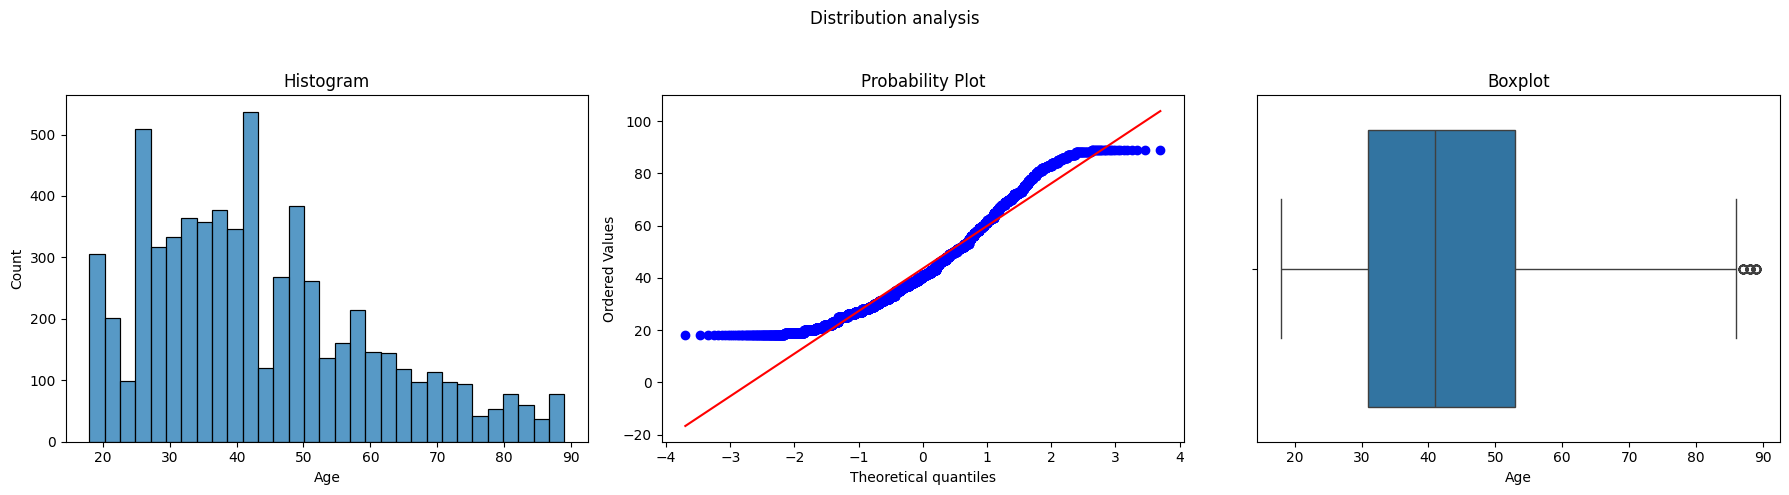

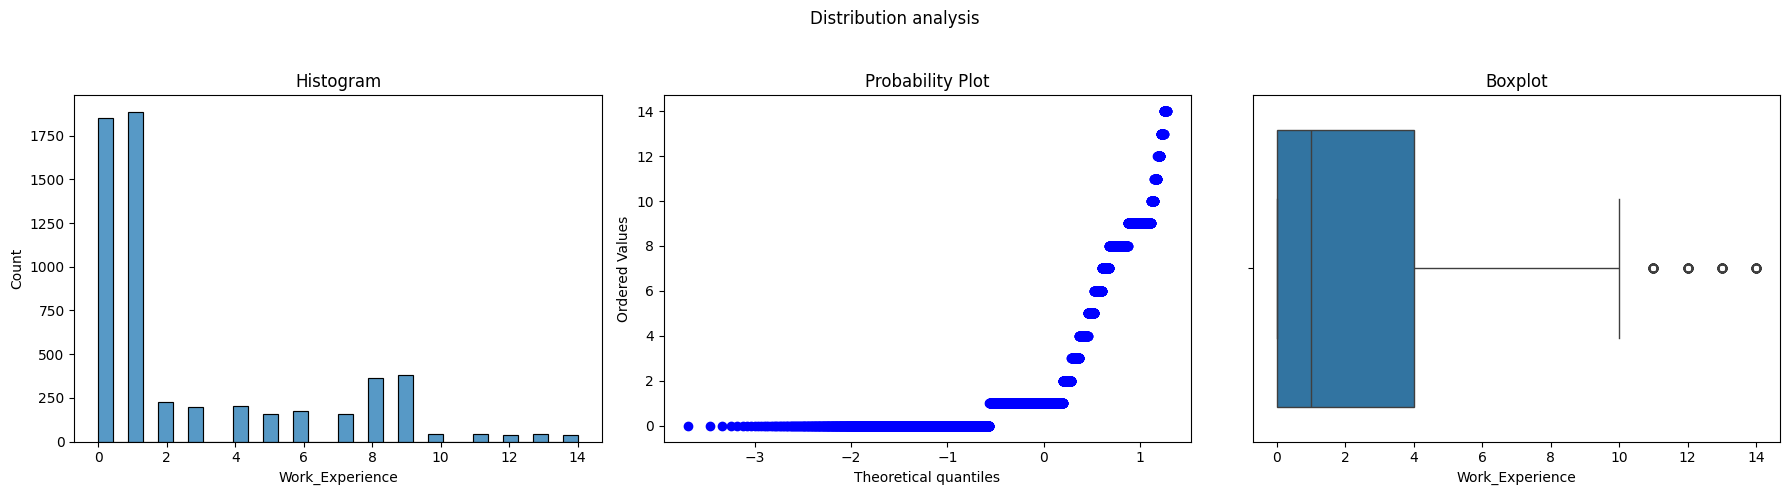

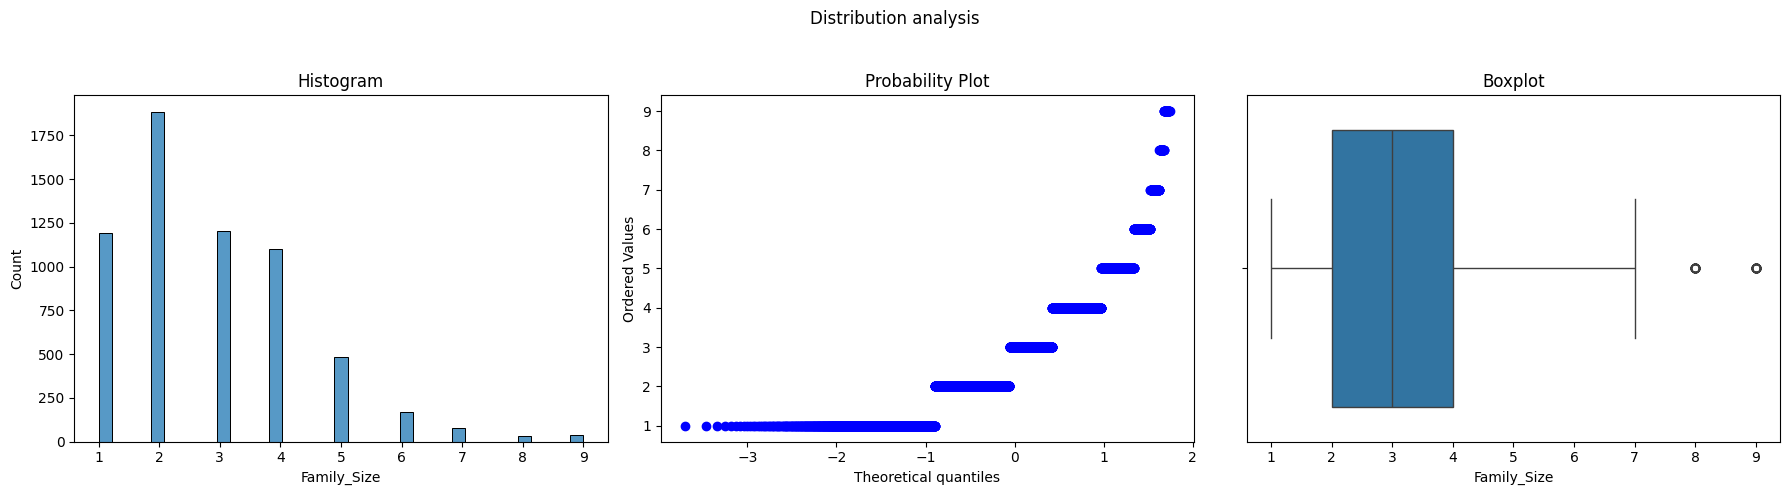

In [12]:
distribution_plot(train_inputs, numeric_cols)

In [13]:
train_inputs['Family_Size'].value_counts()

Family_Size
2.0    1885
3.0    1205
1.0    1195
4.0    1103
5.0     484
6.0     170
7.0      76
9.0      38
8.0      34
Name: count, dtype: int64

In [14]:
print("Частка пропусків:", round((train_inputs['Family_Size'].isna().sum() / train_inputs['Family_Size'].count()) * 100, 2))

Частка пропусків: 4.26


In [15]:
train_inputs[train_inputs['Family_Size'].isna()]

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
1536,Female,Yes,50,Yes,Engineer,0.0,Low,NaN,Cat_6
1538,Male,Yes,73,Yes,Artist,1.0,Average,NaN,Cat_3
665,Female,No,39,Yes,NaN,8.0,Low,NaN,Cat_6
7607,Female,Yes,61,No,Marketing,NaN,Average,NaN,Cat_6
2501,Female,Yes,81,No,Lawyer,1.0,Low,NaN,Cat_3
...,...,...,...,...,...,...,...,...,...
2722,Male,No,18,No,Healthcare,14.0,Low,NaN,Cat_6
7371,Male,No,32,Yes,Healthcare,8.0,Low,NaN,Cat_6
5624,Female,No,36,Yes,Artist,5.0,Low,NaN,Cat_6
7397,Female,No,30,Yes,Healthcare,13.0,Low,NaN,Cat_6


In the case of family size, we will fill in the data with the mode.

In [16]:
family_mode = train_inputs['Family_Size'].mode()[0]
family_mode

np.float64(2.0)

In [17]:
train_inputs['Family_Size'] = train_inputs['Family_Size'].fillna(family_mode)
val_inputs['Family_Size'] = val_inputs['Family_Size'].fillna(family_mode)

In [18]:
print("Частка пропусків:", round((train_inputs['Family_Size'].isna().sum() / train_inputs['Family_Size'].count()) * 100, 2))

Частка пропусків: 0.0


In [19]:
train_inputs['Work_Experience'].value_counts()

Work_Experience
1.0     1886
0.0     1850
9.0      382
8.0      364
2.0      224
4.0      205
3.0      199
6.0      174
7.0      159
5.0      158
10.0      45
11.0      43
13.0      41
12.0      40
14.0      38
Name: count, dtype: int64

In [20]:
print("Частка пропусків:", round((train_inputs['Work_Experience'].isna().sum() / train_inputs['Work_Experience'].count()) * 100, 2))

Частка пропусків: 11.12


In the case of work experience, we will fill in the gaps with the median.

In [21]:
work_median = train_inputs['Work_Experience'].median()
work_median

np.float64(1.0)

In [22]:
train_inputs['Work_Experience'] = train_inputs['Work_Experience'].fillna(work_median)
val_inputs['Work_Experience'] = val_inputs['Work_Experience'].fillna(work_median)

In [23]:
print("Частка пропусків:", round((train_inputs['Work_Experience'].isna().sum() / train_inputs['Work_Experience'].count()) * 100, 2))

Частка пропусків: 0.0


To scale numeric features, we will use MinMaxScaler.

In [24]:
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(train_inputs[numeric_cols])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [25]:
train_inputs[numeric_cols] = minmax_scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = minmax_scaler.transform(val_inputs[numeric_cols])

# Categorical features

In [26]:
train_inputs[categorical_cols].info()

<class 'pandas.core.frame.DataFrame'>
Index: 6454 entries, 917 to 2661
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Gender          6454 non-null   object
 1   Ever_Married    6343 non-null   object
 2   Graduated       6395 non-null   object
 3   Profession      6348 non-null   object
 4   Spending_Score  6454 non-null   object
 5   Var_1           6394 non-null   object
dtypes: object(6)
memory usage: 353.0+ KB


In [27]:
print("Частка пропусків:", round((train_inputs['Gender'].isna().sum() / train_inputs['Gender'].count()) * 100, 2))

Частка пропусків: 0.0


In [28]:
train_inputs['Gender'].head()

917     Female
3398      Male
2045    Female
8060    Female
4604    Female
Name: Gender, dtype: object

Encode the gender feature with a binary variable

In [29]:
gender_codes = {'Female': 1, 'Male': 0}
train_inputs['Gender'] = train_inputs['Gender'].map(gender_codes)
val_inputs['Gender'] = val_inputs['Gender'].map(gender_codes)

In [30]:
train_inputs['Gender'].head()

917     1
3398    0
2045    1
8060    1
4604    1
Name: Gender, dtype: int64

In [31]:
print("Частка пропусків:", round((train_inputs['Ever_Married'].isna().sum() / train_inputs['Ever_Married'].count()) * 100, 2))

Частка пропусків: 1.75


In [32]:
train_inputs['Ever_Married'].head()

917      No
3398    Yes
2045     No
8060    Yes
4604    Yes
Name: Ever_Married, dtype: object

In [33]:
train_inputs['Ever_Married'].value_counts(normalize = True).round(4)

Ever_Married
Yes    0.5887
No     0.4113
Name: proportion, dtype: float64

We impute the Ever_Married attribute using the mode.

In [34]:
marry__mode = train_inputs['Ever_Married'].mode()[0]
marry__mode

'Yes'

In [35]:
train_inputs['Ever_Married'] = train_inputs['Ever_Married'].fillna(marry__mode)
val_inputs['Ever_Married'] = val_inputs['Ever_Married'].fillna(marry__mode)

In [36]:
print("Частка пропусків:", round((train_inputs['Ever_Married'].isna().sum() / train_inputs['Ever_Married'].count()) * 100, 2))

Частка пропусків: 0.0


Regarding encoding, let's fill it with a binary value.

In [37]:
map_codes = {'Yes': 1, 'No': 0}
train_inputs['Ever_Married'] = train_inputs['Ever_Married'].map(map_codes)
val_inputs['Ever_Married'] = val_inputs['Ever_Married'].map(map_codes)

In [38]:
print("Частка пропусків:", round((train_inputs['Graduated'].isna().sum() / train_inputs['Graduated'].count()) * 100, 2))

Частка пропусків: 0.92


Since the proportion of missing values ​​is less than 2%, we will fill them with the mode. As for the coding of the attribute, we will use binary values, as in the case of gender. We will use a similar imputation and coding for the attribute Graduated.

In [39]:
train_inputs['Graduated'].value_counts(normalize = True).round(4)

Graduated
Yes    0.6266
No     0.3734
Name: proportion, dtype: float64

In [40]:
grad_mode = train_inputs['Graduated'].mode()[0]
grad_mode

'Yes'

In [41]:
train_inputs['Graduated'] = train_inputs['Graduated'].fillna(grad_mode)
val_inputs['Graduated'] = val_inputs['Graduated'].fillna(grad_mode)

In [42]:
print("Частка пропусків:", round((train_inputs['Graduated'].isna().sum() / train_inputs['Graduated'].count()) * 100, 2))

Частка пропусків: 0.0


In [43]:
train_inputs['Graduated'] = train_inputs['Graduated'].map(map_codes)
val_inputs['Graduated'] = val_inputs['Graduated'].map(map_codes)

In [44]:
train_inputs['Graduated'].value_counts(normalize = True).round(4)

Graduated
1    0.63
0    0.37
Name: proportion, dtype: float64

In [45]:
print("Частка пропусків:", round((train_inputs['Profession'].isna().sum() / train_inputs['Profession'].count()) * 100, 2))

Частка пропусків: 1.67


In [46]:
train_inputs['Profession'].value_counts(normalize = True).round(4)

Profession
Artist           0.3158
Healthcare       0.1676
Entertainment    0.1174
Doctor           0.0893
Engineer         0.0885
Lawyer           0.0773
Executive        0.0770
Marketing        0.0362
Homemaker        0.0307
Name: proportion, dtype: float64

In [47]:
train_inputs[(train_inputs['Profession'].isna())]

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
665,1,0,0.295775,1,NaN,0.571429,Low,0.125,Cat_6
2313,0,0,0.070423,0,NaN,0.000000,Low,0.875,Cat_4
5043,0,0,0.056338,0,NaN,0.142857,Low,0.125,Cat_3
4707,0,0,0.014085,0,NaN,0.642857,Low,0.375,Cat_4
6558,0,1,0.098592,1,NaN,0.071429,Low,0.125,Cat_7
...,...,...,...,...,...,...,...,...,...
3217,0,1,0.267606,1,NaN,0.000000,Average,0.375,Cat_6
5194,0,1,0.323944,1,NaN,0.071429,Average,0.375,Cat_6
1506,1,0,0.042254,0,NaN,0.071429,Low,0.375,Cat_6
5478,1,0,0.169014,1,NaN,0.571429,Low,0.125,Cat_6


Regarding profession, since in cases where data is missing we observe both the presence and absence of work experience, I propose to impute the omissions with the category 'Unknown' so as not to create unrealistic cases without a known context. We will use LabelEncoding to encode the attribute.

In [48]:
train_inputs['Profession'] = train_inputs['Profession'].fillna('Unknown')
val_inputs['Profession'] = val_inputs['Profession'].fillna('Unknown')

In [49]:
label_encoder = LabelEncoder()
label_encoder.fit(train_inputs['Profession'])

LabelEncoder()

In [50]:
train_inputs['Profession'] = label_encoder.transform(train_inputs['Profession'])
val_inputs['Profession'] = label_encoder.transform(val_inputs['Profession'])

In [51]:
print("Частка пропусків:", round((train_inputs['Spending_Score'].isna().sum() / train_inputs['Spending_Score'].count()) * 100, 2))

Частка пропусків: 0.0


In [52]:
train_inputs['Spending_Score'].head()

917         Low
3398    Average
2045        Low
8060    Average
4604        Low
Name: Spending_Score, dtype: object

To encode Spending_Score, we will use OrdinalEncoder, since the order is explicitly specified in the features.

In [53]:
train_inputs['Spending_Score'].value_counts(normalize = True).round(4)

Spending_Score
Low        0.6043
Average    0.2433
High       0.1525
Name: proportion, dtype: float64

In [54]:
order_encoder = OrdinalEncoder(categories = [['Low', 'Average', 'High']])

In [55]:
order_encoder.fit(train_inputs[['Spending_Score']])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['Low', 'Average', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None


In [56]:
train_inputs['Spending_Score'] = order_encoder.transform(train_inputs[['Spending_Score']])
val_inputs['Spending_Score'] = order_encoder.transform(val_inputs[['Spending_Score']])

In [57]:
print("Частка пропусків:", round((train_inputs['Var_1'].isna().sum() / train_inputs['Var_1'].count()) * 100, 2))

Частка пропусків: 0.94


In [58]:
train_inputs['Var_1'].head()

917     Cat_6
3398    Cat_6
2045    Cat_6
8060    Cat_6
4604    Cat_7
Name: Var_1, dtype: object

In [59]:
train_inputs['Var_1'].value_counts(normalize = True).round(4)

Var_1
Cat_6    0.6567
Cat_4    0.1332
Cat_3    0.1045
Cat_2    0.0535
Cat_7    0.0250
Cat_1    0.0175
Cat_5    0.0095
Name: proportion, dtype: float64

In the case of the anonymized user category variable Var_1, we will use data imputation using mode.

In [60]:
var_mode = train_inputs['Var_1'].mode()[0]
var_mode

'Cat_6'

In [61]:
train_inputs['Var_1'] = train_inputs['Var_1'].fillna('var_mode')
val_inputs['Var_1'] = val_inputs['Var_1'].fillna('var_mode')

In [62]:
print("Частка пропусків:", round((train_inputs['Var_1'].isna().sum() / train_inputs['Var_1'].count()) * 100, 2))

Частка пропусків: 0.0


In the case of Var_1, I also suggest using Label Encoding.

In [63]:
var_label_encoder = LabelEncoder()
var_label_encoder.fit(train_inputs['Var_1'])

LabelEncoder()

In [64]:
train_inputs['Var_1'] = var_label_encoder.transform(train_inputs['Var_1'])
val_inputs['Var_1'] = var_label_encoder.transform(val_inputs['Var_1'])

In [65]:
train_inputs['Var_1'].head()

917     5
3398    5
2045    5
8060    5
4604    6
Name: Var_1, dtype: int64

In [66]:
train_inputs

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1
917,1,0,0.197183,1,0,0.642857,0.0,0.000,5
3398,0,1,0.760563,1,3,0.071429,1.0,0.125,5
2045,1,0,0.211268,1,3,0.071429,0.0,0.375,5
8060,1,1,0.422535,1,0,0.000000,1.0,0.625,5
4604,1,1,0.140845,0,1,0.642857,0.0,0.000,6
...,...,...,...,...,...,...,...,...,...
3822,1,0,0.126761,0,6,0.571429,0.0,0.000,5
5864,0,0,0.267606,1,5,0.000000,0.0,0.125,5
3589,1,0,0.126761,0,2,0.428571,0.0,0.625,3
1489,0,0,0.112676,0,0,0.000000,0.0,0.125,5


# Resampling methods

## Basic SMOTE

In [67]:
X_train_num = train_inputs[numeric_cols]
X_val_num = val_inputs[numeric_cols]

print("Дизайн матриця тренувальної вибірки до застосування SMOTE")
display(X_train_num.head())

print("Цільова метрика тренувальної вибірки до застосування SMOTE")
display(train_targets.head())

Дизайн матриця тренувальної вибірки до застосування SMOTE


,Age,Work_Experience,Family_Size
917,0.197183,0.642857,0.000
3398,0.760563,0.071429,0.125
2045,0.211268,0.071429,0.375
8060,0.422535,0.000000,0.625
4604,0.140845,0.642857,0.000


Цільова метрика тренувальної вибірки до застосування SMOTE


917     A
3398    B
2045    B
8060    A
4604    A
Name: Segmentation, dtype: object

In [68]:
train_targets.value_counts()

Segmentation
D    1814
A    1578
C    1576
B    1486
Name: count, dtype: int64

In [69]:
smote = SMOTE(random_state=0)
X_train_smote, y_train_smote = smote.fit_resample(X_train_num, train_targets)

In [70]:
y_train_smote.value_counts()

Segmentation
A    1814
B    1814
C    1814
D    1814
Name: count, dtype: int64

## SMOTE-TOMEK

In [71]:
smotetomek = SMOTETomek(random_state=0)
X_train_num_smotetomek, y_train_num_smotetomek = smotetomek.fit_resample(X_train_num, train_targets)

In [72]:
y_train_num_smotetomek.value_counts()

Segmentation
D    1762
C    1751
A    1749
B    1744
Name: count, dtype: int64

## SMOTENC

In [73]:
cat_col_index = [train_inputs.columns.get_loc(col) for col in categorical_cols]
cat_col_index

[0, 1, 3, 4, 6, 8]

In [74]:
smotenc = SMOTENC(categorical_features = cat_col_index, random_state = 0)
X_train_smotenc, y_train_smotenc = smotenc.fit_resample(train_inputs, train_targets)

In [75]:
y_train_smotenc.value_counts()

Segmentation
A    1814
B    1814
C    1814
D    1814
Name: count, dtype: int64

## SMOTEN

In [76]:
X_train_cat = train_inputs[categorical_cols]
X_val_cat = val_inputs[categorical_cols]

print("Дизайн матриця тренувальної вибірки до застосування SMOTEN")
display(X_train_cat.head())

Дизайн матриця тренувальної вибірки до застосування SMOTEN


,Gender,Ever_Married,Graduated,Profession,Spending_Score,Var_1
917,1,0,1,0,0.0,5
3398,0,1,1,3,1.0,5
2045,1,0,1,3,0.0,5
8060,1,1,1,0,1.0,5
4604,1,1,0,1,0.0,6


In [77]:
smoten_ = SMOTEN(random_state=0)
X_train_smoten, y_train_smoten = smoten_.fit_resample(X_train_cat, train_targets)

In [78]:
y_train_smoten.value_counts()

Segmentation
A    1814
B    1814
C    1814
D    1814
Name: count, dtype: int64

# One-vs-Rest

## Logistic regression model using One-vs-Rest on original data

In [79]:
log_reg = LogisticRegression(solver='liblinear')

In [80]:
ovr_model_basic = OneVsRestClassifier(log_reg)
ovr_model_basic.fit(train_inputs, train_targets)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

In [81]:
ovr_model_basic_pred = ovr_model_basic.predict(val_inputs)

In [82]:
print(classification_report(val_targets, ovr_model_basic_pred))

              precision    recall  f1-score   support

           A       0.40      0.35      0.37       394
           B       0.41      0.10      0.17       372
           C       0.47      0.67      0.55       394
           D       0.58      0.79      0.67       454

    accuracy                           0.49      1614
   macro avg       0.47      0.48      0.44      1614
weighted avg       0.47      0.49      0.45      1614



## Logistic Regression Model Using One-vs-Rest Balanced Data with SMOTE

In [83]:
ovr_model_smote = OneVsRestClassifier(log_reg)
ovr_model_smote.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

In [84]:
ovr_model_smote_pred = ovr_model_smote.predict(X_val_num)

In [85]:
print(classification_report(val_targets, ovr_model_smote_pred))

              precision    recall  f1-score   support

           A       0.33      0.29      0.31       394
           B       0.28      0.09      0.13       372
           C       0.36      0.42      0.39       394
           D       0.50      0.77      0.60       454

    accuracy                           0.41      1614
   macro avg       0.37      0.39      0.36      1614
weighted avg       0.37      0.41      0.37      1614



## Logistic Regression Model Using One-vs-Rest Balanced Data with SMOTE-TOMEK

In [86]:
ovr_model_smotetomek = OneVsRestClassifier(log_reg)
ovr_model_smotetomek.fit(X_train_num_smotetomek, y_train_num_smotetomek)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

In [87]:
ovr_model_smotetomek_pred = ovr_model_smotetomek.predict(X_val_num)

In [88]:
print(classification_report(val_targets, ovr_model_smotetomek_pred))

              precision    recall  f1-score   support

           A       0.33      0.29      0.31       394
           B       0.26      0.07      0.11       372
           C       0.35      0.43      0.39       394
           D       0.50      0.76      0.60       454

    accuracy                           0.41      1614
   macro avg       0.36      0.39      0.35      1614
weighted avg       0.37      0.41      0.36      1614



## Logistic Regression Model Using One-vs-Rest Balanced Data with SMOTENC

In [89]:
ovr_model_smotenc = OneVsRestClassifier(log_reg)
ovr_model_smotenc.fit(X_train_smotenc, y_train_smotenc)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

In [90]:
ovr_model_smotenc_pred = ovr_model_smotenc.predict(val_inputs)

In [91]:
print(classification_report(val_targets, ovr_model_smotenc_pred))

              precision    recall  f1-score   support

           A       0.42      0.40      0.41       394
           B       0.42      0.17      0.24       372
           C       0.47      0.63      0.54       394
           D       0.61      0.77      0.68       454

    accuracy                           0.51      1614
   macro avg       0.48      0.49      0.47      1614
weighted avg       0.49      0.51      0.48      1614



## Logistic Regression Model Using One-vs-Rest Balanced Data with SMOTEN

In [92]:
ovr_model_smoten = OneVsRestClassifier(log_reg)
ovr_model_smoten.fit(X_train_smoten, y_train_smoten)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=

In [93]:
ovr_model_smoten_pred = ovr_model_smoten.predict(X_val_cat)

In [94]:
print(classification_report(val_targets, ovr_model_smoten_pred))

              precision    recall  f1-score   support

           A       0.37      0.24      0.29       394
           B       0.43      0.17      0.24       372
           C       0.45      0.69      0.55       394
           D       0.57      0.78      0.66       454

    accuracy                           0.48      1614
   macro avg       0.46      0.47      0.43      1614
weighted avg       0.46      0.48      0.45      1614



The main metric was chosen as the F1-score weighted average to assess the overall quality of classification while taking into account the characteristics of each individual class.
As a secondary metric, recall by classes, especially in the case of small classes.

According to the simulation results, the best F1-score weighted average is observed in the case of the logistic regression model using One-vs-Rest balanced data with SMOTENC, the worst result in the case of SMOTE-TOMEK.
Also, compared to all models, it is on SMOTENC that we have the best recall by classes.

There is no significant difference between SMOTE and SMOTE-TOMEK, possibly due to the fact that removing Tomek links does not significantly affect the balance of classes in this case.

# One-vs-One

## Logistic Regression Model Using One-vs-One on Original Data

In [95]:
ovo_model_basic = OneVsOneClassifier(log_reg)
ovo_model_basic.fit(train_inputs, train_targets)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes * (n_classes - 1) / 2` OVO problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough t

In [96]:
ovo_model_basic_pred = ovo_model_basic.predict(val_inputs)

In [97]:
print(classification_report(val_targets, ovo_model_basic_pred))

              precision    recall  f1-score   support

           A       0.43      0.38      0.40       394
           B       0.43      0.19      0.26       372
           C       0.48      0.65      0.55       394
           D       0.62      0.78      0.69       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.48      1614
weighted avg       0.49      0.51      0.49      1614



## Logistic Regression Model Using One-vs-One Balanced Data with SMOTE

In [98]:
ovo_model_smote = OneVsOneClassifier(log_reg)
ovo_model_smote.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes * (n_classes - 1) / 2` OVO problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough t

In [99]:
ovo_model_smote_pred = ovo_model_smote.predict(X_val_num)

In [100]:
print(classification_report(val_targets, ovo_model_smote_pred))

              precision    recall  f1-score   support

           A       0.33      0.30      0.31       394
           B       0.27      0.11      0.16       372
           C       0.35      0.41      0.38       394
           D       0.51      0.72      0.60       454

    accuracy                           0.40      1614
   macro avg       0.36      0.39      0.36      1614
weighted avg       0.37      0.40      0.37      1614



## Logistic Regression Model Using One-vs-One Balanced Data with SMOTE-TOMEK

In [101]:
ovo_model_smotetomek = OneVsOneClassifier(log_reg)
ovo_model_smotetomek.fit(X_train_num_smotetomek, y_train_num_smotetomek)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes * (n_classes - 1) / 2` OVO problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough t

In [102]:
ovo_model_smotetomek_pred = ovo_model_smotetomek.predict(X_val_num)

In [103]:
print(classification_report(val_targets, ovo_model_smotetomek_pred))

              precision    recall  f1-score   support

           A       0.33      0.31      0.32       394
           B       0.28      0.10      0.15       372
           C       0.35      0.42      0.38       394
           D       0.51      0.72      0.60       454

    accuracy                           0.40      1614
   macro avg       0.37      0.39      0.36      1614
weighted avg       0.37      0.40      0.37      1614



## Logistic Regression Model Using One-vs-One Balanced Data with SMOTENC

In [104]:
ovo_model_smotenc = OneVsOneClassifier(log_reg)
ovo_model_smotenc.fit(X_train_smotenc, y_train_smotenc)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes * (n_classes - 1) / 2` OVO problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough t

In [105]:
ovo_model_smotenc_pred = ovo_model_smotenc.predict(val_inputs)

In [106]:
print(classification_report(val_targets, ovo_model_smotenc_pred))

              precision    recall  f1-score   support

           A       0.42      0.37      0.39       394
           B       0.37      0.25      0.30       372
           C       0.50      0.60      0.54       394
           D       0.64      0.75      0.69       454

    accuracy                           0.51      1614
   macro avg       0.48      0.49      0.48      1614
weighted avg       0.49      0.51      0.49      1614



## Logistic Regression Model Using One-vs-One Balanced Data with SMOTEN

In [107]:
ovo_model_smoten = OneVsOneClassifier(log_reg)
ovo_model_smoten.fit(X_train_smoten, y_train_smoten)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes * (n_classes - 1) / 2` OVO problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough t

In [108]:
ovo_model_smoten_pred = ovo_model_smoten.predict(X_val_cat)

In [109]:
print(classification_report(val_targets, ovo_model_smoten_pred))

              precision    recall  f1-score   support

           A       0.36      0.34      0.35       394
           B       0.38      0.21      0.27       372
           C       0.50      0.61      0.55       394
           D       0.60      0.74      0.66       454

    accuracy                           0.49      1614
   macro avg       0.46      0.47      0.46      1614
weighted avg       0.46      0.49      0.47      1614



The main metric was chosen as the F1-score weighted average to assess the overall quality of classification while taking into account the characteristics of each individual class.
As a secondary metric, recall by classes, especially in the case of small classes.

According to the modeling results, the best F1-score weighted average is observed in the case of the logistic regression model using One-vs-One balanced data from SMOTENC and original data, the worst result is in the case of SMOTE-TOMEK. At the same time, if we consider the recall of a small class, then the indicator is higher in the model with balanced SMOTENC data.
Also, compared to all models, it is on SMOTENC that we have the best recall by classes.

There is no significant difference between SMOTE and SMOTE-TOMEK, possibly due to the fact that removing Tomek links in this case does not significantly affect the balance of classes.